# Escuela Politecnica Nacional

Nombre: Joseph Cruz

Fecha: 13/07/2026

Unidad 03-A | Serie de Taylor y Polinomios de Lagrange
## CONJUNTO DE EJERCICIOS
Determine el orden de la mejor aproximación para las siguientes funciones, usando la Serie de Taylor y el Polinomio de Lagrange:
1. $\frac{1}{25 \cdot x^2 + 1}, x_0 = 0$

* Escriba las fórmulas de los diferentes polinomios
* Grafique las diferentes aproximaciones


## Ejercicio 1

### Función

$$
f(x)=\frac{1}{25x^2+1}, \qquad x_0=0
$$

### Serie de Taylor

Al desarrollar la función alrededor de $x_0=0$ se obtiene:

$$
f(x)=1-25x^2+625x^4-15625x^6+\cdots
$$

Por lo tanto, los primeros polinomios de Taylor son:

$$
P_0(x)=1
$$

$$
P_2(x)=1-25x^2
$$

$$
P_4(x)=1-25x^2+625x^4
$$

$$
P_6(x)=1-25x^2+625x^4-15625x^6
$$

### Polinomio de Lagrange

La fórmula general es

$$
P_n(x)=\sum_{i=0}^{n}y_iL_i(x)
$$

donde

$$
L_i(x)=\prod_{j=0,\,j\ne i}^{n}\frac{x-x_j}{x_i-x_j}
$$

En este ejercicio se comparan la función original con las aproximaciones obtenidas mediante Taylor y Lagrange.

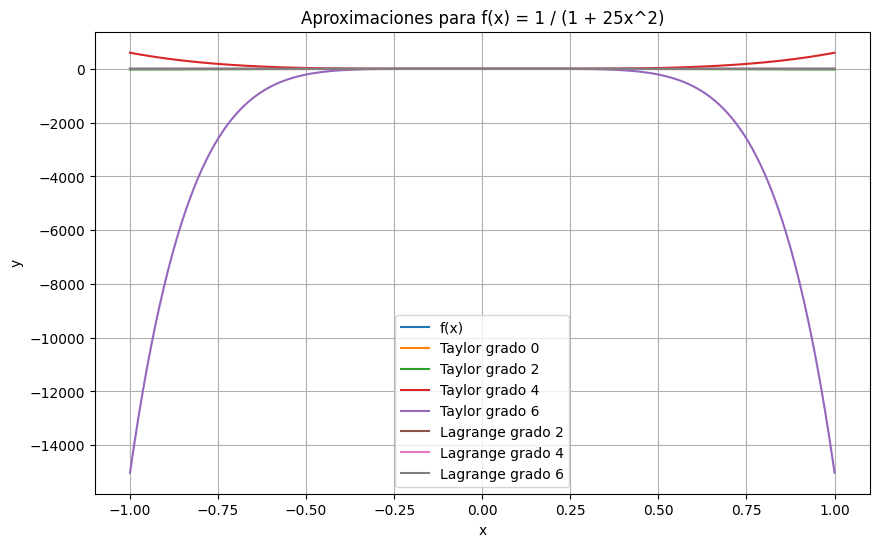

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math

def f1(x):
    return 1 / (1 + 25 * x**2)

def taylor_f1(x, grado):
    s = 0
    for k in range(0, grado + 1, 2):
        s += (-25)**(k // 2) * x**k
    return s

def lagrange(xn, yn, x):
    total = 0
    n = len(xn)
    for i in range(n):
        term = yn[i]
        for j in range(n):
            if i != j:
                term *= (x - xn[j]) / (xn[i] - xn[j])
        total += term
    return total

x = np.linspace(-1, 1, 500)
y = f1(x)

t0 = taylor_f1(x, 0)
t2 = taylor_f1(x, 2)
t4 = taylor_f1(x, 4)
t6 = taylor_f1(x, 6)

xn2 = np.array([-1, 0, 1], dtype=float)
yn2 = f1(xn2)

xn4 = np.array([-1, -0.5, 0, 0.5, 1], dtype=float)
yn4 = f1(xn4)

xn6 = np.array([-1, -0.75, -0.5, 0, 0.5, 0.75, 1], dtype=float)
yn6 = f1(xn6)

l2 = np.array([lagrange(xn2, yn2, xi) for xi in x])
l4 = np.array([lagrange(xn4, yn4, xi) for xi in x])
l6 = np.array([lagrange(xn6, yn6, xi) for xi in x])

plt.figure(figsize=(10, 6))
plt.plot(x, y, label="f(x)")
plt.plot(x, t0, label="Taylor grado 0")
plt.plot(x, t2, label="Taylor grado 2")
plt.plot(x, t4, label="Taylor grado 4")
plt.plot(x, t6, label="Taylor grado 6")
plt.plot(x, l2, label="Lagrange grado 2")
plt.plot(x, l4, label="Lagrange grado 4")
plt.plot(x, l6, label="Lagrange grado 6")
plt.grid(True)
plt.legend()
plt.title("Aproximaciones para f(x) = 1 / (1 + 25x^2)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

2. $\arctan(x), x_0 = 1$


## Ejercicio 2

### Función

$$
\arctan(x), \qquad x_0=1
$$

### Serie de Taylor

Los primeros polinomios de Taylor alrededor de $x_0=1$ son:

$$
P_0(x)=\frac{\pi}{4}
$$

$$
P_1(x)=\frac{\pi}{4}+\frac{1}{2}(x-1)
$$

$$
P_2(x)=\frac{\pi}{4}+\frac{1}{2}(x-1)-\frac{1}{4}(x-1)^2
$$

$$
P_3(x)=\frac{\pi}{4}+\frac{1}{2}(x-1)-\frac{1}{4}(x-1)^2+\frac{1}{12}(x-1)^3
$$

$$
P_5(x)=\frac{\pi}{4}+\frac{1}{2}(x-1)-\frac{1}{4}(x-1)^2+\frac{1}{12}(x-1)^3-\frac{1}{40}(x-1)^5
$$

$$
P_6(x)=\frac{\pi}{4}+\frac{1}{2}(x-1)-\frac{1}{4}(x-1)^2+\frac{1}{12}(x-1)^3-\frac{1}{40}(x-1)^5+\frac{1}{48}(x-1)^6
$$

### Polinomio de Lagrange

La fórmula general es

$$
P_n(x)=\sum_{i=0}^{n}y_iL_i(x)
$$

donde

$$
L_i(x)=\prod_{j=0,\,j\ne i}^{n}\frac{x-x_j}{x_i-x_j}
$$

En este ejercicio se comparan la función original con las aproximaciones obtenidas mediante Taylor y Lagrange.


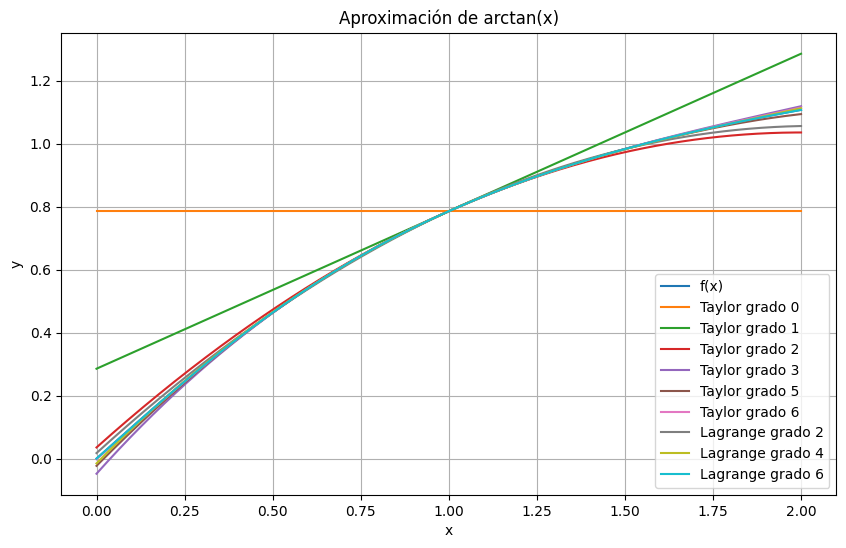

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math

def f2(x):
    return np.arctan(x)

def taylor_f2(x, grado):
    u = x - 1
    s = np.full_like(x, math.pi / 4, dtype=float)

    if grado >= 1:
        s += (1/2) * u

    if grado >= 2:
        s += (-1/4) * u**2

    if grado >= 3:
        s += (1/12) * u**3

    if grado >= 4:
        s += 0 * u**4

    if grado >= 5:
        s += (-1/40) * u**5

    if grado >= 6:
        s += (1/48) * u**6

    return s

def lagrange(xn, yn, x):
    total = 0

    for i in range(len(xn)):
        termino = yn[i]

        for j in range(len(xn)):
            if i != j:
                termino *= (x - xn[j]) / (xn[i] - xn[j])

        total += termino

    return total

x = np.linspace(0, 2, 500)
y = f2(x)

t0 = taylor_f2(x, 0)
t1 = taylor_f2(x, 1)
t2 = taylor_f2(x, 2)
t3 = taylor_f2(x, 3)
t5 = taylor_f2(x, 5)
t6 = taylor_f2(x, 6)

xn2 = np.array([0.5, 1.0, 1.5])
yn2 = f2(xn2)

xn4 = np.array([0.2, 0.7, 1.0, 1.3, 1.8])
yn4 = f2(xn4)

xn6 = np.array([0.0, 0.4, 0.8, 1.0, 1.2, 1.6, 2.0])
yn6 = f2(xn6)

l2 = np.array([lagrange(xn2, yn2, xi) for xi in x])
l4 = np.array([lagrange(xn4, yn4, xi) for xi in x])
l6 = np.array([lagrange(xn6, yn6, xi) for xi in x])

plt.figure(figsize=(10,6))

plt.plot(x, y, label="f(x)")
plt.plot(x, t0, label="Taylor grado 0")
plt.plot(x, t1, label="Taylor grado 1")
plt.plot(x, t2, label="Taylor grado 2")
plt.plot(x, t3, label="Taylor grado 3")
plt.plot(x, t5, label="Taylor grado 5")
plt.plot(x, t6, label="Taylor grado 6")

plt.plot(x, l2, label="Lagrange grado 2")
plt.plot(x, l4, label="Lagrange grado 4")
plt.plot(x, l6, label="Lagrange grado 6")

plt.title("Aproximación de arctan(x)")
plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)
plt.legend()

plt.show()